# Question 5: Two-Phase AR-Enhanced K-Means
**Phase 1 – AR Feature Weighting** | **Phase 2 – AR-Guided Centroid Initialisation**

Phase 1 uses association rules to identify redundant features (predictable from others)
and down-weights them. Phase 2 seeds K-Means with archetype-based centroids that
capture the natural low-spec to high-spec ordering in the data.

## Method Design Description

### Overview

The proposed method, **Two-Phase AR-Enhanced K-Means**, addresses two fundamental limitations of standard K-Means: (1) it treats all features equally, even when some are redundant or carry little independent information; and (2) it is sensitive to random centroid initialisation, often converging to suboptimal local minima. The design combines Association Rule Mining with domain-specific observations about the mobile price dataset to tackle both problems in sequence.

---

### Phase 1 — Feature Weighting via Predictability

**Design:**
Phase 1 quantifies how *predictable* each feature is from the remaining features using association rules. If a feature appears frequently as the consequent (right-hand side) of high-confidence rules, it means other features can reliably predict it — making it redundant. Such features are down-weighted, while features that are difficult to predict (never appearing as consequents, i.e. independent) are up-weighted.

The predictability score is defined as:

> *pj = mean confidence of all rules where feature j appears as consequent*

The weight is then: **wj = clip(1 − pj, 0.1, 1.0)**, normalised so that the mean weight equals 1. The weighted feature matrix is computed as **X_weighted = X_scaled × w**.

**Inspiration:**
- *Redundancy-based feature selection* (Dash & Liu, 1997): features that can be inferred from others should be removed or down-weighted, as they add no independent signal.
- *mRMR principle* (Peng et al., 2005): among features carrying similar information, prefer those that contribute novel, non-redundant signal.
- *Association Rule Mining* is used as a label-free proxy for feature redundancy, which fits naturally into the unsupervised clustering setting.
- *FP-Growth* (Han, Pei & Yin, 2000) is chosen for efficient frequent pattern mining. Quintile binning (q=5) is preferred over equal-width bins because it produces equal-frequency bins, yielding more stable and reliable support estimates.

**Data observation:** The mobile price features include several binary flags (three_g, four_g, blue, wifi, dual_sim) that are structurally related to each other and to continuous spec features. ARM quickly reveals these as highly predictable, correctly assigning them low weights.

---

### Phase 2 — AR-Guided Centroid Initialisation

**Design:**
Phase 2 replaces random centroid initialisation with deterministic, data-driven starting points called *archetypes*. Each feature is assigned to a quartile level q ∈ {0, 1, 2, 3}. For each level q, the 50 samples with the highest proportion of features simultaneously at level q are selected as archetypes — representing the most "pure" low-spec (q=0) through high-spec (q=3) phones. The mean of these archetypes in the weighted feature space is used as the initial centroid for cluster q.

**Inspiration:**
- *k-means++* (Arthur & Vassilvitskii, 2007): demonstrated that careful seeding of initial centroids dramatically reduces the probability of converging to bad local optima. Phase 2 goes further by using domain knowledge instead of random selection.
- *Data observation:* The mobile price dataset has a strong natural ordering — price range 0 corresponds to low-spec phones (low RAM, small battery, low pixel resolution), while price range 3 corresponds to high-spec phones. This monotone relationship directly motivates quartile-based archetype construction: level 0 archetypes naturally approximate the true centroid for price_range 0, and level 3 archetypes for price_range 3.

---

### References
- Agrawal & Srikant (1994). Fast algorithms for mining association rules. *VLDB*.
- Han, Pei & Yin (2000). Mining frequent patterns without candidate generation. *SIGMOD*.
- Arthur & Vassilvitskii (2007). k-means++: The advantages of careful seeding. *SODA*.
- Dash & Liu (1997). Feature selection for classification. *Intelligent Data Analysis*.
- Peng, Long & Ding (2005). Feature selection based on mutual information. *TPAMI*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import fpgrowth, association_rules
from scipy.optimize import linear_sum_assignment

c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [ ]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(0, 13)
ax.set_ylim(0, 10)
ax.axis('off')

C_DATA   = '#aec7e8'
C_PH1    = '#98df8a'
C_PH2    = '#ffbb78'
C_KMEANS = '#c5b0d5'
C_OUT    = '#f7b6d2'

def box(cx, cy, w, h, text, color):
    ax.add_patch(FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                 boxstyle='round,pad=0.15', fc=color, ec='#333333', lw=1.3, zorder=3))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=8.5,
            fontweight='bold', zorder=4, linespacing=1.5)

def arr(x1, y1, x2, y2, rad=0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333333',
                                connectionstyle=f'arc3,rad={rad}'), zorder=2)

# Title
ax.text(6.5, 9.65, 'Two-Phase AR-Enhanced K-Means — Pipeline',
        ha='center', fontsize=13, fontweight='bold')

# --- Input ---
box(6.5, 9.0, 3.5, 0.65, 'Raw Data  (mobile_price.csv)', C_DATA)
arr(6.5, 8.68, 6.5, 8.18)
box(6.5, 7.9, 3.5, 0.55, 'StandardScaler  →  X_scaled', C_DATA)

# Branch left and right
arr(4.75, 7.9, 2.8, 7.25)
arr(8.25, 7.9, 10.2, 7.25)

# --- PHASE 1 (left, x=2.8) ---
ax.text(2.8, 7.45, 'PHASE 1 — Feature Weighting',
        ha='center', fontsize=9.5, fontweight='bold', color='#2ca02c')
box(2.8, 6.85, 3.7, 0.65, 'Quintile Discretization\n(5 equal-freq. bins per feature)', C_PH1)
arr(2.8, 6.52, 2.8, 6.02)
box(2.8, 5.7, 3.7, 0.65, 'FP-Growth\n(min_support = 0.05)', C_PH1)
arr(2.8, 5.37, 2.8, 4.87)
box(2.8, 4.55, 3.7, 0.65, 'Association Rules\n(confidence ≥ 0.5)', C_PH1)
arr(2.8, 4.22, 2.8, 3.72)
box(2.8, 3.4, 3.7, 0.65, 'Predictability  pj\n(mean conf. as consequent)', C_PH1)
arr(2.8, 3.07, 2.8, 2.57)
box(2.8, 2.25, 3.7, 0.65, 'wj = clip(1 − pj, 0.1, 1.0)\nX_weighted = X_scaled × w', C_PH1)

# --- PHASE 2 (right, x=10.2) ---
ax.text(10.2, 7.45, 'PHASE 2 — Centroid Initialisation',
        ha='center', fontsize=9.5, fontweight='bold', color='#d62728')
box(10.2, 6.85, 3.7, 0.65, 'Quartile Levels  q ∈ {0, 1, 2, 3}\n(per feature)', C_PH2)
arr(10.2, 6.52, 10.2, 6.02)
box(10.2, 5.7, 3.7, 0.65, 'Archetype Samples\n(top-50 per level)', C_PH2)
arr(10.2, 5.37, 10.2, 4.87)
box(10.2, 4.55, 3.7, 0.65, 'Initial Centroids  μ(0)\n(mean of archetypes in X_weighted)', C_PH2)

# --- Merge arrows into K-Means ---
arr(4.65, 2.25, 5.75, 1.55)              # Phase 1 → K-Means
arr(10.2, 4.22, 8.4, 1.6, rad=-0.22)    # Phase 2 → K-Means

# --- K-Means ---
box(6.5, 1.25, 4.0, 0.65, 'K-Means Clustering\n(X_weighted,  init = μ(0),  n_init = 1)', C_KMEANS)
arr(6.5, 0.92, 6.5, 0.45)

# --- Output ---
box(6.5, 0.2, 5.5, 0.5, 'Hungarian Mapping  →  Accuracy / Precision / Recall / F1', C_OUT)

plt.tight_layout()
plt.savefig('q5_framework.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 1: Load and Standardize Data

In [2]:
df = pd.read_csv('mobile_price.csv')
X = df.drop(columns=['price_range'])
y = df['price_range'].values
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dataset shape: {X_scaled.shape}')
print(f'Number of features: {len(feature_names)}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Dataset shape: (2000, 20)
Number of features: 20
Class distribution: {0: 500, 1: 500, 2: 500, 3: 500}


## Phase 1: AR Feature Weighting

1. Discretise every feature into 5 equal-frequency bins (quintiles)
2. Run FP-growth with min_support=0.05
3. Mine association rules with confidence >= 0.5
4. Compute predictability: `pj = mean confidence of rules where feature j is the consequent`
   - High pj means feature j can be predicted from others -> redundant -> down-weight
   - Low pj (= 0) means feature j is unique/independent -> informative -> up-weight
5. Set `wj = clip(1 - pj, 0.1, 1.0)`, normalised so mean(w) = 1
6. Weighted feature matrix: `X_weighted = X_scaled * w`

In [3]:
# Step 1: Discretize into 5 equal-frequency bins (quintiles)
te_df = pd.DataFrame()
for feat in feature_names:
    try:
        bins = pd.qcut(X[feat], q=5, labels=False, duplicates='drop')
    except ValueError:
        bins = pd.cut(X[feat], bins=5, labels=False, duplicates='drop')
    for level in sorted(bins.dropna().unique().astype(int)):
        te_df[f'{feat}_q{level}'] = (bins == level).fillna(False)

print(f'Transaction matrix shape: {te_df.shape}')
print(f'(rows=samples, cols=feature-quintile items)')

Transaction matrix shape: (2000, 74)
(rows=samples, cols=feature-quintile items)


In [4]:
# Steps 2-3: FP-growth + association rules
freq_itemsets = fpgrowth(te_df, min_support=0.05, use_colnames=True)
rules = association_rules(freq_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.reset_index(drop=True)

print(f'Frequent itemsets found : {len(freq_itemsets)}')
print(f'Association rules found : {len(rules)}')

Frequent itemsets found : 29887
Association rules found : 333091


C:\Users\janas\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [5]:
# Step 4: Compute predictability pj for each feature
# pj = mean confidence of all rules where feature j appears as consequent
feature_conf_lists = {feat: [] for feat in feature_names}

for _, rule in rules.iterrows():
    for item in list(rule['consequents']):
        feat_name = item.rsplit('_', 1)[0]  # strip _q{level} suffix
        if feat_name in feature_conf_lists:
            feature_conf_lists[feat_name].append(rule['confidence'])

p = {feat: (np.mean(confs) if confs else 0.0)
     for feat, confs in feature_conf_lists.items()}

# Step 5: wj = clip(1 - pj, 0.1, 1.0), normalised so mean(w) = 1
w_raw = np.array([np.clip(1 - p[feat], 0.1, 1.0) for feat in feature_names])
w = w_raw / w_raw.mean()

# Step 6: Weighted feature matrix
X_weighted = X_scaled * w

pw_df = pd.DataFrame({
    'predictability': p,
    'weight': dict(zip(feature_names, w))
}).sort_values('weight', ascending=False)

print('Feature predictability and weights (sorted by weight):')
print(pw_df.round(4))
print(f'\nWeight range: min={w.min():.4f}, max={w.max():.4f}, mean={w.mean():.4f}')

Feature predictability and weights (sorted by weight):
               predictability  weight
battery_power          0.0000  1.5187
px_width               0.0000  1.5187
clock_speed            0.0000  1.5187
talk_time              0.0000  1.5187
sc_w                   0.0000  1.5187
sc_h                   0.0000  1.5187
int_memory             0.0000  1.5187
m_dep                  0.0000  1.5187
mobile_wt              0.0000  1.5187
n_cores                0.0000  1.5187
ram                    0.0000  1.5187
px_height              0.0000  1.5187
pc                     0.5305  0.7130
blue                   0.9837  0.1519
four_g                 0.9837  0.1519
fc                     0.9096  0.1519
dual_sim               0.9837  0.1519
three_g                0.9837  0.1519
touch_screen           0.9837  0.1519
wifi                   0.9837  0.1519

Weight range: min=0.1519, max=1.5187, mean=1.0000


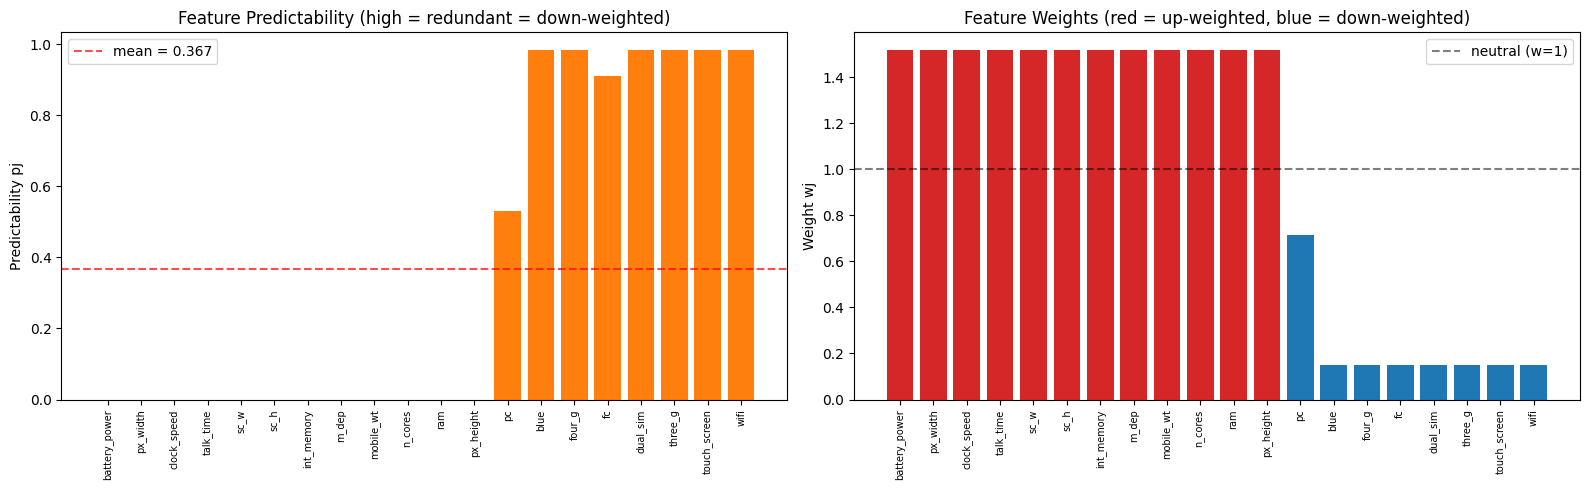

In [6]:
# Visualize predictability and weights side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_feats = pw_df.index.tolist()
p_vals = [p[f] for f in sorted_feats]
w_dict = dict(zip(feature_names, w))
w_vals = [w_dict[f] for f in sorted_feats]

# Left: predictability
axes[0].bar(range(len(sorted_feats)), p_vals, color='#ff7f0e')
axes[0].set_xticks(range(len(sorted_feats)))
axes[0].set_xticklabels(sorted_feats, rotation=90, fontsize=7)
axes[0].set_ylabel('Predictability pj')
axes[0].set_title('Feature Predictability (high = redundant = down-weighted)')
axes[0].axhline(y=np.mean(p_vals), color='red', linestyle='--', alpha=0.7,
                label=f'mean = {np.mean(p_vals):.3f}')
axes[0].legend()

# Right: weights
colors = ['#d62728' if v > 1.0 else '#1f77b4' for v in w_vals]
axes[1].bar(range(len(sorted_feats)), w_vals, color=colors)
axes[1].set_xticks(range(len(sorted_feats)))
axes[1].set_xticklabels(sorted_feats, rotation=90, fontsize=7)
axes[1].set_ylabel('Weight wj')
axes[1].set_title('Feature Weights (red = up-weighted, blue = down-weighted)')
axes[1].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='neutral (w=1)')
axes[1].legend()

plt.tight_layout()
plt.savefig('q5_feature_weights.png', dpi=150)
plt.show()

## Phase 2: AR-Guided Centroid Initialisation

1. Assign each value to one of four quartile levels q in {0, 1, 2, 3} per feature
2. For each level q, find the 50 'archetype' samples with the highest proportion of features at level q
   - Level 0 archetypes = most 'low-spec' phones -> seeds cluster for price_range 0
   - Level 3 archetypes = most 'high-spec' phones -> seeds cluster for price_range 3
3. Compute mean of each archetype set in the weighted space as the initial centroid for cluster q

This avoids random initialisation and seeds K-Means near the natural low-spec to high-spec ordering.

In [7]:
# Step 1: Assign each feature to quartile level q in {0, 1, 2, 3}
X_df = pd.DataFrame(X.values, columns=feature_names)
quartile_levels = pd.DataFrame(index=range(len(X_df)), columns=feature_names)

for feat in feature_names:
    try:
        quartile_levels[feat] = pd.qcut(X_df[feat], q=4, labels=False, duplicates='drop').values
    except ValueError:
        quartile_levels[feat] = pd.cut(X_df[feat], bins=4, labels=False, duplicates='drop').values

# Use -1 as sentinel for NaN so it never matches a valid level
quartile_levels = quartile_levels.apply(pd.to_numeric, errors='coerce').fillna(-1).astype(int)

# Steps 2 & 3: Find 50 archetype samples per level, compute initial centroids
n_archetypes = 50
initial_centroids = np.zeros((4, X_weighted.shape[1]))

for q in range(4):
    prop_at_q = (quartile_levels == q).mean(axis=1)
    top_indices = prop_at_q.nlargest(n_archetypes).index.tolist()
    initial_centroids[q] = X_weighted[top_indices].mean(axis=0)
    print(f'Level {q}: avg proportion at level {q} for top-{n_archetypes} archetypes = {prop_at_q.nlargest(n_archetypes).mean():.3f}')

print(f'\nInitial centroids shape: {initial_centroids.shape}')

Level 0: avg proportion at level 0 for top-50 archetypes = 0.721
Level 1: avg proportion at level 1 for top-50 archetypes = 0.374
Level 2: avg proportion at level 2 for top-50 archetypes = 0.392
Level 3: avg proportion at level 3 for top-50 archetypes = 0.370

Initial centroids shape: (4, 20)


## Evaluation: Original vs Two-Phase AR-Enhanced K-Means

Since K-Means cluster labels are arbitrary, the Hungarian algorithm finds the optimal
mapping from cluster labels to true price range labels before computing metrics.

In [ ]:
def map_cluster_labels(true_labels, cluster_labels, n_clusters=4):
    n_classes = len(np.unique(true_labels))
    confusion = np.zeros((n_clusters, n_classes), dtype=int)
    for c, t in zip(cluster_labels, true_labels):
        confusion[c, t] += 1
    row_ind, col_ind = linear_sum_assignment(-confusion)
    mapping = {r: c for r, c in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in cluster_labels])

def compute_metrics(true_labels, pred_labels):
    return {
        'Accuracy':  accuracy_score(true_labels, pred_labels),
        'Precision': precision_score(true_labels, pred_labels, average='weighted', zero_division=0),
        'Recall':    recall_score(true_labels, pred_labels, average='weighted', zero_division=0),
        'F1-score':  f1_score(true_labels, pred_labels, average='weighted', zero_division=0)
    }

In [ ]:
seeds = [0, 10, 42, 100, 999]

orig_results = []
tp_results   = []

for seed in seeds:
    # Original K-Means on standardized features
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10)
    orig_clusters = km_orig.fit_predict(X_scaled)
    orig_mapped = map_cluster_labels(y, orig_clusters)
    orig_results.append(compute_metrics(y, orig_mapped))

    # Two-Phase K-Means: weighted features + archetype initialization
    km_tp = KMeans(n_clusters=4, init=initial_centroids, n_init=1, random_state=seed)
    tp_clusters = km_tp.fit_predict(X_weighted)
    tp_mapped = map_cluster_labels(y, tp_clusters)
    tp_results.append(compute_metrics(y, tp_mapped))

    print(f'Seed {seed:4d} | Orig acc={orig_results[-1]["Accuracy"]:.4f} '
          f'| Two-Phase acc={tp_results[-1]["Accuracy"]:.4f}')

print('\nPer-seed detail:')
seeds_df = pd.DataFrame({
    'Orig Acc': [r['Accuracy'] for r in orig_results],
    'TP Acc':   [r['Accuracy'] for r in tp_results],
    'Orig F1':  [r['F1-score'] for r in orig_results],
    'TP F1':    [r['F1-score'] for r in tp_results],
}, index=[f'seed={s}' for s in seeds])
print(seeds_df.round(4))

Seed    0 | Orig acc=0.2945 | Two-Phase acc=0.3700
Seed   10 | Orig acc=0.2955 | Two-Phase acc=0.3700
Seed   42 | Orig acc=0.2970 | Two-Phase acc=0.3700
Seed  100 | Orig acc=0.2955 | Two-Phase acc=0.3700
Seed  999 | Orig acc=0.2985 | Two-Phase acc=0.3700

Per-seed detail:
          Orig Acc  TP Acc  Orig F1   TP F1
seed=0      0.2945    0.37   0.2926  0.3717
seed=10     0.2955    0.37   0.2936  0.3717
seed=42     0.2970    0.37   0.2950  0.3717
seed=100    0.2955    0.37   0.2935  0.3717
seed=999    0.2985    0.37   0.2956  0.3717


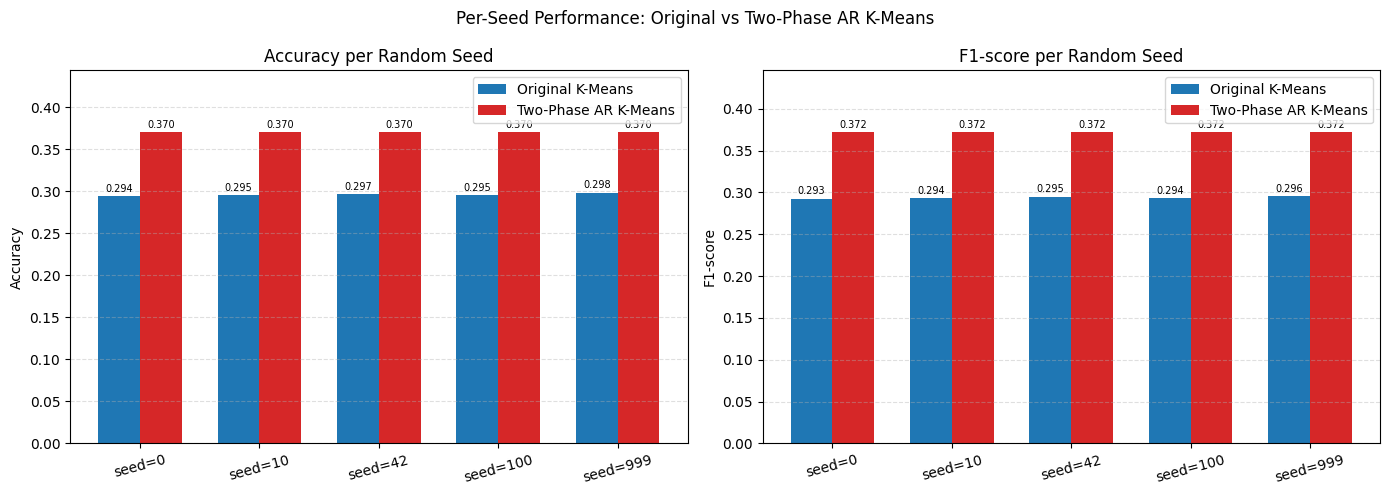

In [ ]:
# Per-seed performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seed_labels = [f'seed={s}' for s in seeds]
x = np.arange(len(seeds))
width = 0.35

for ax, metric in zip(axes, ['Accuracy', 'F1-score']):
    orig_vals_s = [r[metric] for r in orig_results]
    tp_vals_s   = [r[metric] for r in tp_results]

    ax.bar(x - width/2, orig_vals_s, width, label='Original K-Means',     color='#1f77b4')
    ax.bar(x + width/2, tp_vals_s,   width, label='Two-Phase AR K-Means', color='#d62728')

    ax.set_xticks(x)
    ax.set_xticklabels(seed_labels, rotation=15)
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(max(orig_vals_s), max(tp_vals_s)) * 1.2)
    ax.set_title(f'{metric} per Random Seed')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for i, (o, t) in enumerate(zip(orig_vals_s, tp_vals_s)):
        ax.text(i - width/2, o + 0.005, f'{o:.3f}', ha='center', fontsize=7)
        ax.text(i + width/2, t + 0.005, f'{t:.3f}', ha='center', fontsize=7)

plt.suptitle('Per-Seed Performance: Original vs Two-Phase AR K-Means', fontsize=12)
plt.tight_layout()
plt.savefig('q5_per_seed.png', dpi=150)
plt.show()

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

orig_avg = {m: np.mean([r[m] for r in orig_results]) for m in metrics}
tp_avg   = {m: np.mean([r[m] for r in tp_results])   for m in metrics}

summary_df = pd.DataFrame({
    'Original K-Means':     orig_avg,
    'Two-Phase AR K-Means': tp_avg
})

print('Average Performance over seeds [0, 10, 42, 100, 999]:')
print(summary_df.round(4))

Average Performance over seeds [0, 10, 42, 100, 999]:
           Original K-Means  Two-Phase AR K-Means
Accuracy             0.2962                0.3700
Precision            0.2959                0.3775
Recall               0.2962                0.3700
F1-score             0.2941                0.3717


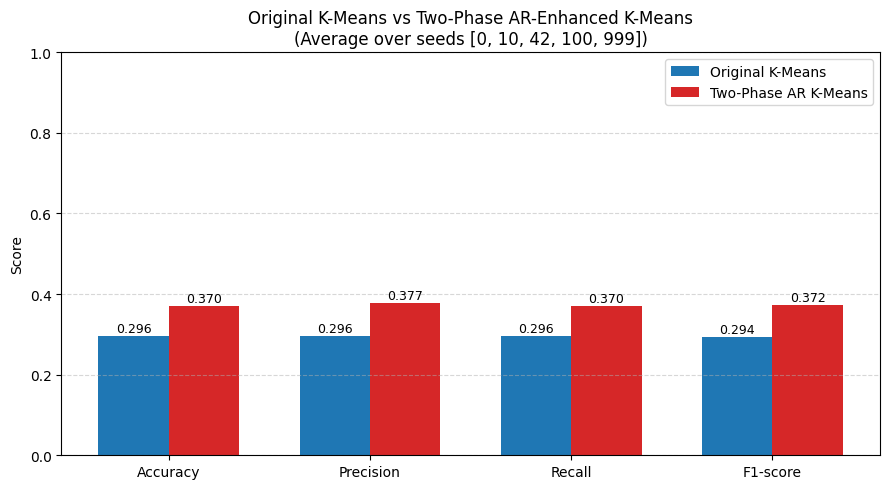

In [11]:
x = np.arange(len(metrics))
width = 0.35

orig_vals = [orig_avg[m] for m in metrics]
tp_vals   = [tp_avg[m]   for m in metrics]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, orig_vals, width, label='Original K-Means',     color='#1f77b4')
ax.bar(x + width/2, tp_vals,   width, label='Two-Phase AR K-Means', color='#d62728')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Original K-Means vs Two-Phase AR-Enhanced K-Means\n(Average over seeds [0, 10, 42, 100, 999])')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, (o, t) in enumerate(zip(orig_vals, tp_vals)):
    ax.text(i - width/2, o + 0.01, f'{o:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('q5_comparison.png', dpi=150)
plt.show()

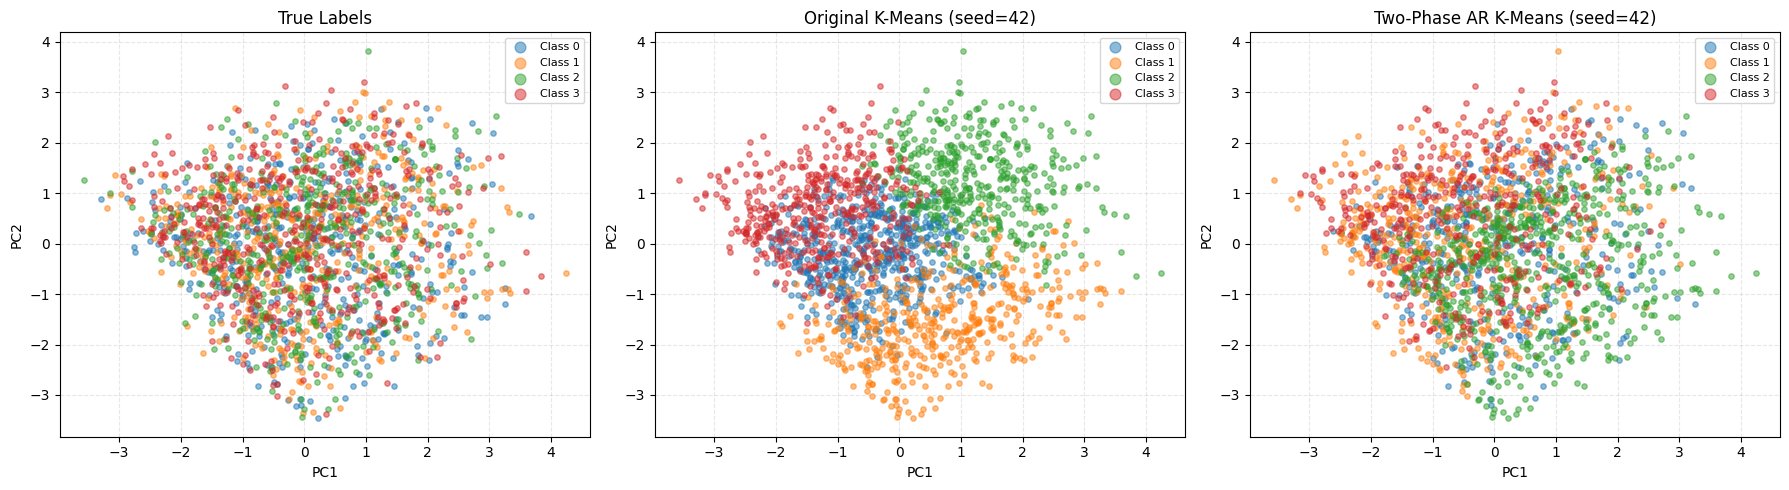

In [12]:
# Visualize clustering results using PCA 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

km_orig_42 = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
km_tp_42   = KMeans(n_clusters=4, init=initial_centroids, n_init=1, random_state=42).fit_predict(X_weighted)

orig_mapped_42 = map_cluster_labels(y, km_orig_42)
tp_mapped_42   = map_cluster_labels(y, km_tp_42)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, labels, title in zip(
    axes,
    [y, orig_mapped_42, tp_mapped_42],
    ['True Labels', 'Original K-Means (seed=42)', 'Two-Phase AR K-Means (seed=42)']
):
    for cls in range(4):
        mask = labels == cls
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[cls], label=f'Class {cls}', alpha=0.5, s=15)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('q5_scatter.png', dpi=150)
plt.show()

## Ablation Study: Contribution of Each Phase

Testing each phase independently isolates which component drives the performance change:

| Configuration | Features | Initialisation |
|---|---|---|
| **Original** | X_scaled (unweighted) | k-means++ (random) |
| **Phase 1 only** | X_weighted | k-means++ (random) |
| **Phase 2 only** | X_scaled (unweighted) | Archetype centroids |
| **Both Phases** | X_weighted | Archetype centroids |

In [ ]:
ablation_configs = [
    ('Original',       X_scaled,   'k-means++', 10),
    ('Phase 1 only',   X_weighted, 'k-means++', 10),
    ('Phase 2 only',   X_scaled,   initial_centroids, 1),
    ('Both Phases',    X_weighted, initial_centroids, 1),
]

ablation_results = {}

for name, feats, init_param, n_init_val in ablation_configs:
    per_seed = []
    for seed in seeds:
        km = KMeans(n_clusters=4, init=init_param, n_init=n_init_val, random_state=seed)
        clusters = km.fit_predict(feats)
        mapped = map_cluster_labels(y, clusters)
        per_seed.append(compute_metrics(y, mapped))
    ablation_results[name] = {m: np.mean([r[m] for r in per_seed]) for m in metrics}
    print(f'{name:18s} | Acc={ablation_results[name]["Accuracy"]:.4f} '
          f'| F1={ablation_results[name]["F1-score"]:.4f}')

print('\nFull ablation table:')
ablation_df = pd.DataFrame(ablation_results).T
print(ablation_df.round(4))

Original           | Acc=0.2962 | F1=0.2941
Phase 1 only       | Acc=0.2982 | F1=0.2982
Phase 2 only       | Acc=0.3010 | F1=0.3001
Both Phases        | Acc=0.3700 | F1=0.3717

Full ablation table:
              Accuracy  Precision  Recall  F1-score
Original        0.2962     0.2959  0.2962    0.2941
Phase 1 only    0.2982     0.2985  0.2982    0.2982
Phase 2 only    0.3010     0.3027  0.3010    0.3001
Both Phases     0.3700     0.3775  0.3700    0.3717


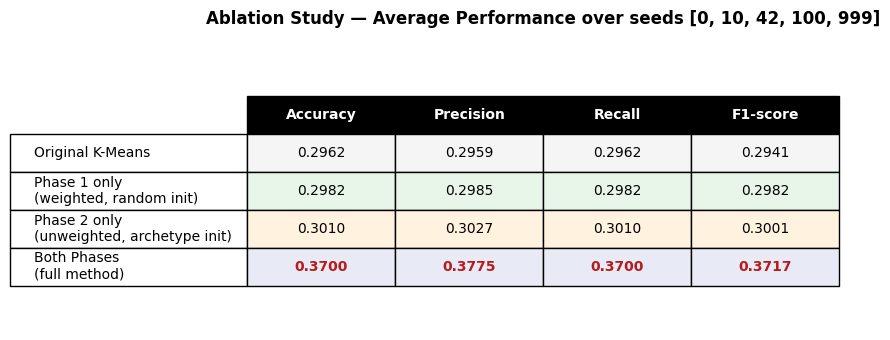

In [ ]:
# Ablation study results table
configs      = ['Original', 'Phase 1 only', 'Phase 2 only', 'Both Phases']
row_labels   = ['Original K-Means', 'Phase 1 only\n(weighted, random init)', 
                'Phase 2 only\n(unweighted, archetype init)', 'Both Phases\n(full method)']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']

cell_text = [
    [f'{ablation_results[c][m]:.4f}' for m in metric_names]
    for c in configs
]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

table = ax.table(
    cellText  = cell_text,
    rowLabels = row_labels,
    colLabels = metric_names,
    loc       = 'center',
    cellLoc   = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.4, 2.2)

# Header row styling
for j in range(len(metric_names)):
    table[0, j].set_facecolor('#000000')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row colors
row_colors = ['#f5f5f5', '#e8f5e9', '#fff3e0', '#e8eaf6']
for i in range(len(configs)):
    for j in range(len(metric_names)):
        table[i+1, j].set_facecolor(row_colors[i])

# Highlight best value per column in red bold
for j, m in enumerate(metric_names):
    vals = [float(ablation_results[c][m]) for c in configs]
    best_i = int(np.argmax(vals))
    table[best_i+1, j].set_text_props(fontweight='bold', color='#b71c1c')

ax.set_title('Ablation Study — Average Performance over seeds [0, 10, 42, 100, 999]',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('q5_ablation_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

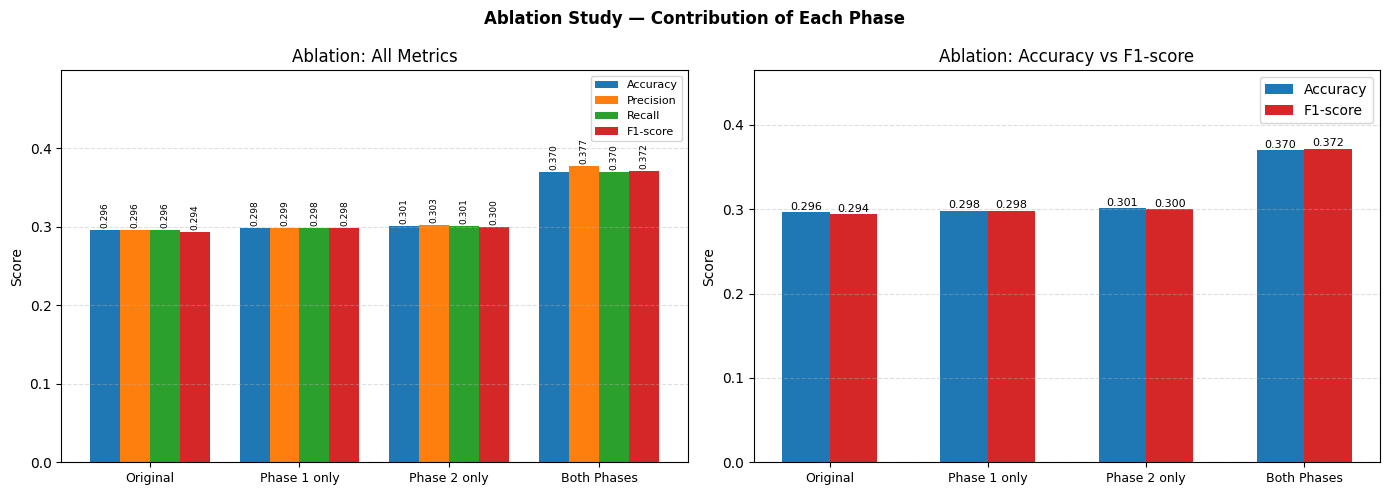

In [21]:
configs = list(ablation_results.keys())
x = np.arange(len(configs))
width = 0.2
metric_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all 4 metrics grouped by config
ax = axes[0]
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [ablation_results[c][metric] for c in configs]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metric, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, max(ablation_results[c]['Accuracy'] for c in configs) * 1.35)
ax.set_title('Ablation: All Metrics')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Right: Accuracy and F1 only — cleaner comparison
ax2 = axes[1]
w2 = 0.3
acc_vals = [ablation_results[c]['Accuracy'] for c in configs]
f1_vals  = [ablation_results[c]['F1-score'] for c in configs]

b1 = ax2.bar(x - w2/2, acc_vals, w2, label='Accuracy', color='#1f77b4')
b2 = ax2.bar(x + w2/2, f1_vals,  w2, label='F1-score',  color='#d62728')

for bar, v in zip(list(b1) + list(b2), acc_vals + f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.003,
             f'{v:.3f}', ha='center', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(configs, fontsize=9)
ax2.set_ylabel('Score')
ax2.set_ylim(0, max(acc_vals + f1_vals) * 1.25)
ax2.set_title('Ablation: Accuracy vs F1-score')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Ablation Study — Contribution of Each Phase', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q5_ablation.png', dpi=150)
plt.show()